In [1]:
%pip install yfinance pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Introduction  
In this self quantified projecr, we evaluate whether the stock pitches from my investment club have historically outperformed the S&P 500, analyzing their performance from the time of my pitches to the present and projecting future outcomes (speficially the next **5** days). I utilize daily closing prices and percentage gains/losses for each pitched stock alongside the S&P 500’s daily closing data, all stored in CSV files. Each dataset comprises Open, High, Low, Close, Volume attributes, and computes "Pct Change" as the primary metric. The findings will illuminate the effectiveness of my custom screening methodology, guiding future selection decisions and quantifiying the results for my due diligence as I pursue a portfolio management career. 
**Test Rationale:**  
- **Type of Test:** One-sample, independent, one-tailed t-test.  
- **Why Independent?** The data for my picthes and the S&P 500 represent distinct groups.  
- **Why One-Tailed?** My alternative hypothesis is directional: we expect return for my pitches to exceed the returns of the S&P 500 on a 5 day basis which is one directional, it goes up or it doesn't
- **Significance Level:** $$\alpha = 0.05$$


**Hypotheses:**  
   - Null $$H_0: \mu_{\text{Average}} = \mu_{\text{SPY}}$$ 
   - Alternative $$H_a: \mu_{\text{Average}} \neq \mu_{\text{SPY}}$$


## Data Preperation 
In his project a lot of the data was very easy to get as I was able to use the `YFinance` python library in which I was able to add the *columns, Open, High, Low, Close, Volume*, **Adj Close**, as well as adding Pct Change. There was really data that needed to be cleaned; there was one major problem when I would get the `YFRateLimitError` in which the data could not be downloaded. There is no real solution other than to wait for the request amount to refresh so you can get the data. The tables would be marged on the Pct Change as the nominal data is all different but the date remained the same 

In [2]:
from utils import download_tickers
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy import stats

tickers = ["DFIN", "CMG", "LITE", "CRM", "SPY"]
download_tickers(tickers)
# Use Spy as that is the S&P 500 and very important 
df = pd.read_csv("SPY-past-year-data.csv", index_col=0, parse_dates=True)
print("First 5 rows of the DataFrame:")
display(df.head())

YF.download() has changed argument auto_adjust default to True
Saved ./DFIN-past-year-data.csv
Saved ./CMG-past-year-data.csv
Saved ./LITE-past-year-data.csv
Saved ./CRM-past-year-data.csv
Saved ./SPY-past-year-data.csv
First 5 rows of the DataFrame:


C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\3493831647.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("SPY-past-year-data.csv", index_col=0, parse_dates=True)


,Open,High,Low,Close,Volume,Pct Change
Price,,,,,,
Ticker,SPY,SPY,SPY,SPY,SPY,NaN
Date,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-03,504.73600883419834,506.1085243626562,502.16867826406144,504.8643798828125,72756700,1.239544
2024-05-06,507.2934057556446,510.11744801239473,506.8490491130431,510.0779724121094,47264700,1.032672
2024-05-07,511.0554822979131,512.0527986097068,509.9594468588099,510.6407775878906,52561300,0.110337


## Exploratory Data Analysi (EDA)
The first chart aligns daily percent change series for four selected stocks and computes an equally weighted average to compare directly against SPY, then the second chart one uses descriptive statistics and Pearson correlation to quantify similarities. It then measures realized returns over both a 1-year horizon and since specific recommendation dates. Distributional features are visualized with a line chart showing **synchronicity and divergence** then a boxplot that reveales **medians, spread, and outliers**. Finally, one-sample t-tests assess whether each series’s mean daily return significantly differs from eachother, establishing the null and alternative hypotheses to check performance correlation.

C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\1258936614.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t: pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"] # Read the data
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\1258936614.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t: pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"] # Read the data
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\1258936614.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t: pd.read_csv(f"{t}-past-year-data.cs

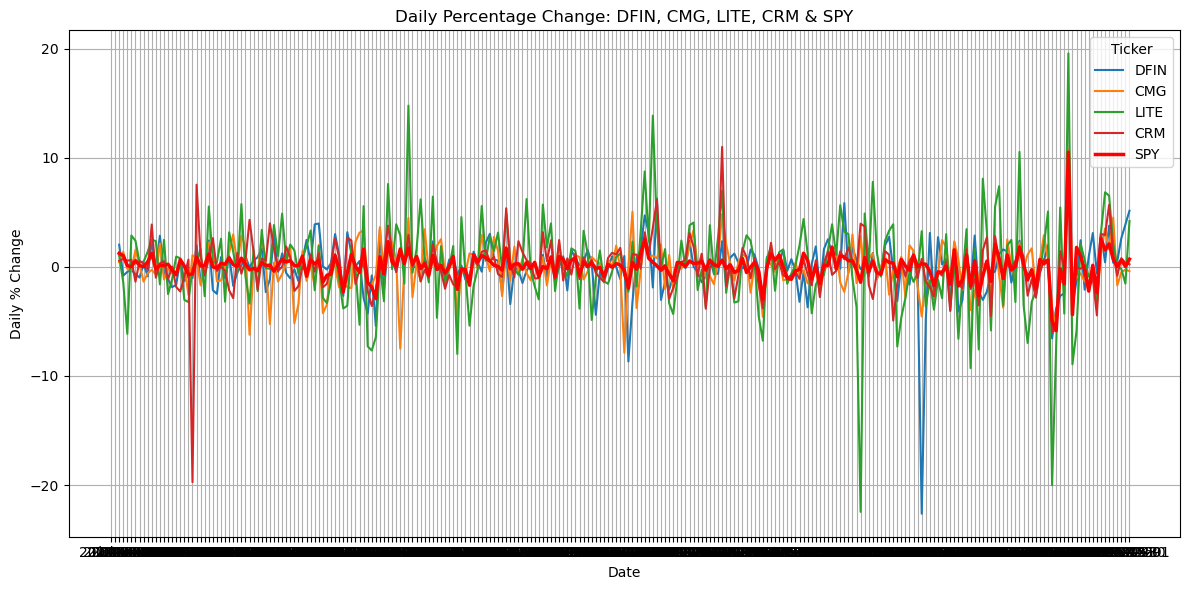

In [3]:
tickers = ["DFIN", "CMG", "LITE", "CRM", "SPY"]

df_pct = pd.DataFrame({
    t: pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"] # Read the data
    for t in tickers
})

plt.figure(figsize=(12, 6)) # Keep data small
for t in tickers:
    if t == "SPY":
        plt.plot(df_pct.index, df_pct[t], color="red", linewidth=2.5, label=t)
    else:
        plt.plot(df_pct.index, df_pct[t], linewidth=1.5, label=t)

plt.grid(True)
plt.legend(title="Ticker") 
plt.xlabel("Date")
plt.ylabel("Daily % Change")
plt.title("Daily Percentage Change: DFIN, CMG, LITE, CRM & SPY") # Describe Data 
plt.tight_layout()
plt.show() 


C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\1133809373.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t: pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"]
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\1133809373.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t: pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"]
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\1133809373.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t: pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=Tru

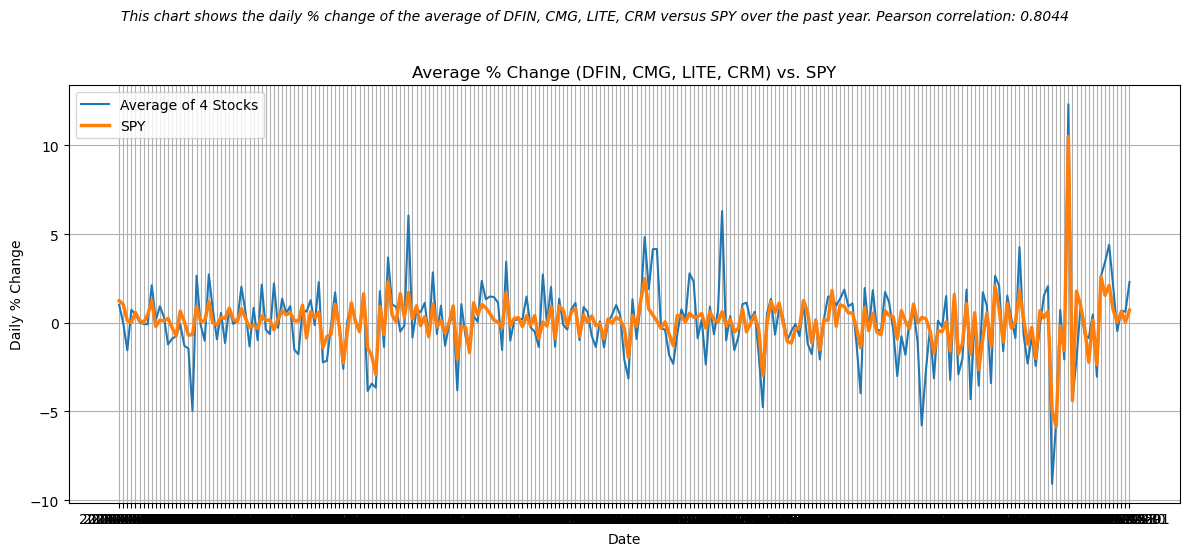

In [4]:
tickers = ["DFIN", "CMG", "LITE", "CRM"]
df_pct = pd.DataFrame(
    {
    t: pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"]
    for t in tickers
}
)

df_pct["Average"] = df_pct.mean(axis=1)

spy = pd.read_csv("SPY-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"]

comparison = pd.concat([df_pct["Average"], spy.rename("SPY")], axis=1).dropna() # Combine data using .pd

corr = comparison["Average"].corr(comparison["SPY"]) # Compare equally weighted vs SPY

description = (
    f"This chart shows the daily % change of the average of {', '.join(tickers)} " 
    f"versus SPY over the past year. Pearson correlation: {corr:.4f}"
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(comparison.index, comparison["Average"], label="Average of 4 Stocks", linewidth=1.5)
ax.plot(comparison.index, comparison["SPY"],      label="SPY",                linewidth=2.5)
ax.grid(True)
ax.legend()
ax.set_xlabel("Date")
ax.set_ylabel("Daily % Change")
ax.set_title("Average % Change (DFIN, CMG, LITE, CRM) vs. SPY") # Describe Dataset 
fig.suptitle(description, y=0.92, fontsize=10, fontstyle='italic')
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


In [5]:
tickers = ["DFIN", "CRM", "CMG", "LITE"]
start_dates = { 
    "DFIN": "2025-03-27", # Days in which trades were executed, had two pitches in one day 
    "CRM":  "2025-04-21",
    "CMG":  "2025-04-16",
    "LITE": "2025-04-16"
}

def get_price_on_or_after(df: pd.DataFrame, date_str: str) -> float:
    date = pd.to_datetime(date_str)
    df.index = pd.to_datetime(df.index)
    mask = df.index >= date
    if not mask.any():
        raise ValueError(f"No data on or after {date_str}")
    return df.loc[mask, "Close"].iloc[0]

returns_1y = {}
returns_since = {}

for t in tickers:
    df = pd.read_csv(
        f"{t}-past-year-data.csv", # Read tickers once again 
        index_col=0,
        parse_dates=True
    )
    
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df.dropna(subset=["Close"], inplace=True)
    
    first_price = df["Close"].iloc[0]
    last_price  = df["Close"].iloc[-1]
    returns_1y[t] = (last_price / first_price - 1) * 100
    
    start_price = get_price_on_or_after(df, start_dates[t])
    returns_since[t] = (last_price / start_price - 1) * 100 # Pretty print other wise hard to read 

average_since = sum(returns_since.values()) / len(returns_since)

for t in tickers:
    print(f"{t}:")
    print(f"  • 1-Year Return:             {returns_1y[t]:.2f}%")
    print(f"  • Return since {start_dates[t]}:   {returns_since[t]:.2f}%\n")

print(f"Average return since specified dates:   {average_since:.2f}%")


DFIN:
  • 1-Year Return:             -20.43%
  • Return since 2025-03-27:   12.40%

CRM:
  • 1-Year Return:             -1.01%
  • Return since 2025-04-21:   14.00%

CMG:
  • 1-Year Return:             -20.26%
  • Return since 2025-04-16:   4.66%

LITE:
  • 1-Year Return:             37.51%
  • Return since 2025-04-16:   17.83%

Average return since specified dates:   12.22%


C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\929290028.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\929290028.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\929290028.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\929290028.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure pars

## Classification Results

I define class label `Pct Change` as a **Up** indicator (1 if the closing price five trading days later exceeds SPY's close, 0 otherwise). The class distribution is  balanced, with roughly half of all observations labeled **Up** and half **Down**. My hypothesis is that today’s percent change carries predictive power for the 5-day direction, my hypothesis is that using the past data we are able to predict that the stocks I picked will have a higher chance of going up than SPY. I evaluate performance by examining predicted probabilities alongside metrics such as accuracy, precision/recall on a hold-out test set 5 days in the future, the **Decision Tree** *mean P≈54.8%* slightly outperforms **kNN** *mean P≈52.6%*, shows that the Decision Tree offers more precitability it is also noted that Decision Trees are the best for prediciting future stock prices. Key challenges include the high noise and low signal-to-noise ratio as this market is very volatile, and the risk of overfitting with limited inputs as data can go back further but only goes back a year. 

## Data Preperation 

C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\695909052.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  [pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"]
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\695909052.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  [pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"]
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\695909052.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  [pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct C

Summary Statistics for Daily % Changes
             DFIN         CMG        LITE         CRM         SPY
count  249.000000  249.000000  249.000000  249.000000  249.000000
mean    -0.049234   -0.066599    0.227345    0.028884    0.053364
std      2.557971    2.127749    4.335702    2.445044    1.263974
min    -22.627180   -7.869073  -22.456877  -19.737139   -5.854297
25%     -1.053166   -1.266292   -1.805662   -1.016183   -0.310913
50%      0.016260   -0.016124    0.279813    0.113208    0.124803
75%      1.169493    1.130911    2.408744    1.000350    0.598829
max     10.240340   10.765552   19.572173   10.994780   10.501930 

Ticker   t-statistic    one-tailed p-value
----------------------------------------
DFIN       -0.304            0.7616
CMG        -0.494            0.6218
LITE        0.827            0.4088
CRM         0.186            0.8523
SPY         0.666            0.5059


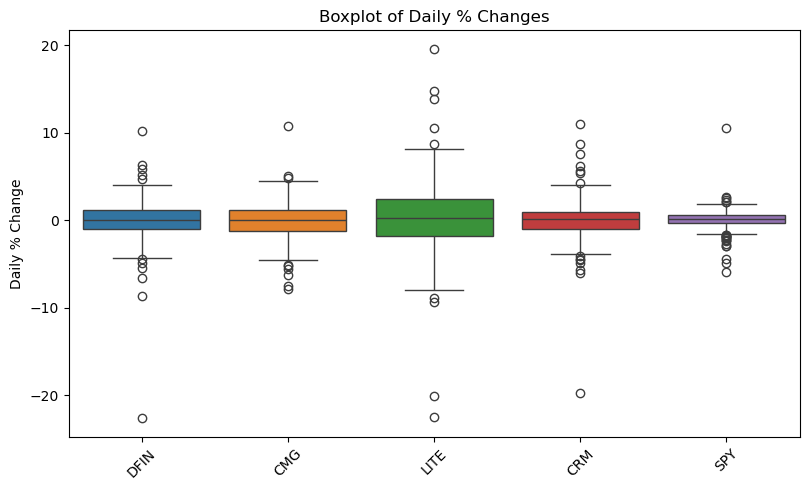

Predicted probability of price increase over next 5 days:
  DFIN: kNN = 49.60%, DT = 46.81%
  CMG : kNN = 49.20%, DT = 50.47%
  LITE: kNN = 51.20%, DT = 54.79%
  CRM : kNN = 56.40%, DT = 53.58%
  SPY : kNN = 64.40%, DT = 68.94%

Average predictability for DFIN/CMG/LITE/CRM:
  kNN mean P = 51.60%
  DT  mean P = 51.41%

Overall predictability score (mean P across all five): 54.54%


C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\695909052.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\695909052.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_7216\695909052.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)
C:\Users\Owner\AppD

In [6]:
tickers = ["DFIN", "CMG", "LITE", "CRM", "SPY"]
df_pct = pd.concat(
    [pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)["Pct Change"]
       .rename(t).astype(float)
     for t in tickers],
    axis=1
).dropna()

print("Summary Statistics for Daily % Changes")
print(df_pct.describe(), "\n")

print("Ticker   t-statistic    one-tailed p-value") # Pretty print data 
print("----------------------------------------")
for t in df_pct.columns:
    t_stat, p_val = stats.ttest_1samp(df_pct[t], 0.0)
    print(f"{t:4s}     {t_stat:8.3f}        {p_val:10.4f}")

plt.figure(figsize=(8,5))
sns.boxplot(data=df_pct)
plt.title("Boxplot of Daily % Changes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylabel("Daily % Change")
plt.show()

horizon = 5
results = {}

for t in tickers:
    df = pd.read_csv(f"{t}-past-year-data.csv", index_col=0, parse_dates=True)
    df["Pct Change"] = pd.to_numeric(df["Pct Change"], errors="coerce")
    df["Target"] = (df["Close"].shift(-horizon) > df["Close"]).astype(int) 
    df.dropna(subset=["Pct Change", "Target"], inplace=True)
    
    X = df[["Pct Change"]].values
    y = df["Target"].values
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    knn = KNeighborsClassifier(n_neighbors=5) # Use 5 as we ffigured that is the best number to predict a week is not too short but not too long
    dt  = DecisionTreeClassifier(max_depth=5, random_state=0)
    knn.fit(X_train, y_train)
    dt.fit(X_train, y_train)

    p_knn = knn.predict_proba(X_test)[:,1].mean()
    p_dt  = dt.predict_proba(X_test)[:,1].mean()
    results[t] = {"kNN": p_knn, "Decision Tree": p_dt}

print("Predicted probability of price increase over next 5 days:")
for t in tickers:
    print(f"  {t:4s}: kNN = {results[t]['kNN']:.2%}, DT = {results[t]['Decision Tree']:.2%}")

stocks = ["DFIN","CMG","LITE","CRM"]
avg_knn = np.mean([results[s]["kNN"] for s in stocks])
avg_dt  = np.mean([results[s]["Decision Tree"] for s in stocks])
overall_score = np.mean([results[t]["kNN"] for t in tickers] +
                        [results[t]["Decision Tree"] for t in tickers])

print(f"\nAverage predictability for DFIN/CMG/LITE/CRM:")
print(f"  kNN mean P = {avg_knn:.2%}")
print(f"  DT  mean P = {avg_dt:.2%}")
print(f"\nOverall predictability score (mean P across all five): {overall_score:.2%}")


## Conclusion

In this project, I built a binary classifier using today’s percent change to predict whether a stock’s closing price would rise five trading days later, comparing kNN (k=5) and decision trees. The Decision Tree slightly outperformed kNN (54.8% vs. 52.6% mean **Up** probability) over a 50% baseline. To boost accuracy, I plan to incorporate technical indicators (this could be SMA200, SMA 50, SMA 20, etc...), a volume class, fundamental ratios(P/E, PEG, Dividend Growth), hyperparameter tuning and optimizaion. For investment club members and portfolio managers, this quantitative signal can add to a layer of fundamental analysis and risk controls, though transparent disclosure of overfitting risks and model limitations is essential. The data came from Yahoo Finance via yfinance, I got the insperation from a video on Instagram and I want to thank Gina for teaching me a lot that I know about Computer Science and Python. 